# Setups

In [ ]:
%%capture
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cpu.html
!pip install torch-geometric

In [ ]:
import os
import json
import gzip
import random
import collections
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

import networkx as nx
from networkx.algorithms import bipartite

import torch
import torch.nn.functional as F
import torch_geometric.transforms as T
from torch import Tensor, nn, optim
from torch_sparse import SparseTensor, matmul
from torch_geometric.utils import from_networkx
from torch_geometric.utils import structured_negative_sampling
from torch_geometric.utils import negative_sampling
from torch_geometric.nn import GCNConv
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.conv.gcn_conv import gcn_norm

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# I. Smaller Dataset (Applicances)

## a. Read Data

In [ ]:
# load the digital music data
data = []
with gzip.open('/content/Appliances_5.json.gz') as f:
    for l in f:
        data.append(json.loads(l.strip()))
    
# total length of list, this number equals total number of products
print('The number of reviews: ', len(data))

# first row of the list
print(data[0])

The number of reviews:  2277
{'overall': 5.0, 'verified': True, 'reviewTime': '08 22, 2013', 'reviewerID': 'A34A1UP40713F8', 'asin': 'B00009W3I4', 'style': {'Style:': ' Dryer Vent'}, 'reviewerName': 'James. Backus', 'reviewText': 'I like this as a vent as well as something that will keep house warmer in winter.  I sanded it and then painted it the same color as the house.  Looks great.', 'summary': 'Great product', 'unixReviewTime': 1377129600}


## b. View Data Frame

In [ ]:
# convert list into pandas dataframe
reviews = pd.DataFrame.from_dict(data)
reviews.head()

,overall,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,vote,image
0,5.0,True,"08 22, 2013",A34A1UP40713F8,B00009W3I4,{'Style:': ' Dryer Vent'},James. Backus,I like this as a vent as well as something tha...,Great product,1377129600,NaN,NaN
1,5.0,True,"02 8, 2016",A1AHW6I678O6F2,B00009W3PA,{'Size:': ' 6-Foot'},kevin.,good item,Five Stars,1454889600,NaN,NaN
2,5.0,True,"08 5, 2015",A8R48NKTGCJDQ,B00009W3PA,{'Size:': ' 6-Foot'},CDBrannom,Fit my new LG dryer perfectly.,Five Stars,1438732800,NaN,NaN
3,5.0,True,"04 24, 2015",AR3OHHHW01A8E,B00009W3PA,{'Size:': ' 6-Foot'},Calvin E Reames,Good value for electric dryers,Perfect size,1429833600,NaN,NaN
4,5.0,True,"03 21, 2015",A2CIEGHZ7L1WWR,B00009W3PA,{'Size:': ' 6-Foot'},albert j. kong,Price and delivery was excellent.,Five Stars,1426896000,NaN,NaN


## c. Simple Sampling - 20 reviewers

In [ ]:
# simple sample (20 reviewers)
reviewerID = reviews['reviewerID'].unique()
products = reviews['asin'].unique()

reviewer_product_match = collections.defaultdict(int)

for d in data:
  reviewer_product_match[d['reviewerID']] += 1

filtered_reviewers = []
for key in reviewer_product_match.keys():
  if(reviewer_product_match[key] >= 5):
    filtered_reviewers.append(key)

# randomly choose 20 reviewers
filtered_reviewers = random.sample(filtered_reviewers, 20)
print(filtered_reviewers) # the 20 reviewers chosen

sampled_data = []

for d in data:
  if d['reviewerID'] in filtered_reviewers:
    sampled_data.append(d)

sampled_df = pd.DataFrame(sampled_data)
sampled_df = sampled_df[['reviewerID', 'asin', 'overall']] # only take these three columns
sampled_df.head()

['A2B2JVUX5YN8RU', 'A2O7BWHBIV1HWZ', 'A2OP8DEIIUESP', 'A3TMNU7VNK5JJE', 'A1IT56MV1C09VS', 'A1T1YSCDW0PD25', 'A1LN48DHHCKLR3', 'A2HDUVKXR5CM7H', 'A3GP2HMB2AFOKF', 'A2V0JXLJ9VCNNX', 'A1HWFUO5PKB2RW', 'A11SCLK8GDDN3C', 'A3NHUQ33CFH3VM', 'A6FPI5CM4W5WB', 'A3LGZ8M29PBNGG', 'A23KSPVPHZF6EO', 'ALZOND1IEW8KS', 'A2CIEGHZ7L1WWR', 'A34A1UP40713F8', 'A3VYM3NY7W4MX4']


,reviewerID,asin,overall
0,A34A1UP40713F8,B00009W3I4,5.0
1,A2CIEGHZ7L1WWR,B00009W3PA,5.0
2,A3LGZ8M29PBNGG,B000N6302Q,2.0
3,A3LGZ8M29PBNGG,B000N6302Q,2.0
4,A3GP2HMB2AFOKF,B000NCTOUM,5.0


## d. Bipartite Graph - B

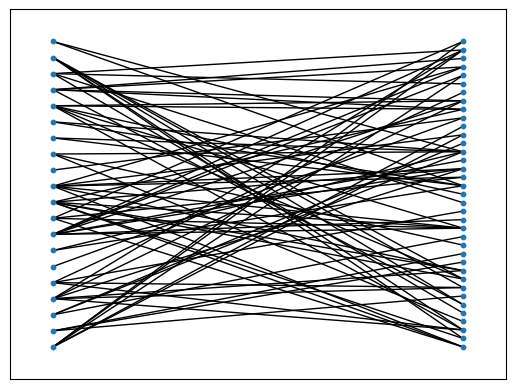

Total number of nodes:  57
Total number of edges:  80


In [ ]:
# create bipartite reviewer/product graph
def add_bipartite_edges(data, graph, domain1, domain2, weight):
  edges = []
  weighted_edges = []
  for index, row in data.iterrows():
    graph.add_weighted_edges_from([(row[domain1],row[domain2],row[weight])], weight="weight")
    edges.append((row[domain1], row[domain2]))
    weighted_edges.append([row[domain1], row[domain2], row[weight]])
  return edges, weighted_edges

# Bipartite graph - B
B = nx.Graph()

reviewerID = sampled_df['reviewerID'].unique()
products = sampled_df['asin'].unique()

B.add_nodes_from(reviewerID, bipartite=0)
B.add_nodes_from(products, bipartite=1)

edges, weighted_edges = add_bipartite_edges(sampled_df, B, 0, 1, 2)

pos = nx.bipartite_layout(B, reviewerID)

nx.draw_networkx(B, pos, with_labels=False, node_size=10)
plt.show()

print('Total number of nodes: ', B.number_of_nodes())
print('Total number of edges: ', B.number_of_edges())

## e. One-Mode Projections - O

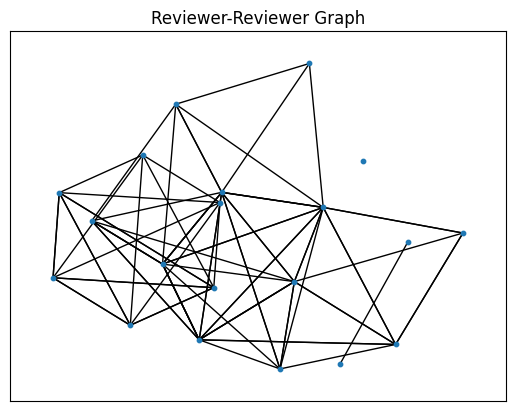

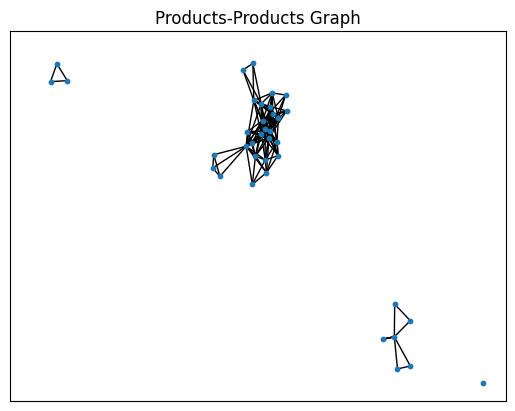

In [ ]:
# One mode projection (reviewerID)
O = nx.projected_graph(B, reviewerID, multigraph=True)
pos = nx.kamada_kawai_layout(O) # kamada kawai layout

nx.draw_networkx(O, pos=pos, with_labels = False, node_size = 10)
plt.title("Reviewer-Reviewer Graph")
plt.show()

print(' ')

# One mode projection (products)
O = nx.projected_graph(B, products, multigraph=True)
pos = nx.fruchterman_reingold_layout(O) # fruchterman reingold layout

nx.draw_networkx(O, with_labels = False, node_size = 10)
plt.title("Products-Products Graph")
plt.show()

## f. Adjacency Matrix - A

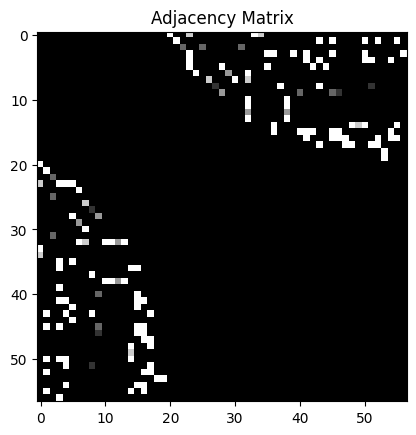

In [ ]:
# Adjacency matrix - A
A = nx.adjacency_matrix(B)
A = A.toarray()

plt.title("Adjacency Matrix")
plt.imshow(A, cmap = 'gray')
plt.show()

## g. Calculate Modularity Q

In [ ]:
# compute the modularity of this adjacency matrix
print('The modularity of this bipartite network is: ', nx.community.modularity(B, [reviewerID, products]),\
      '< 0' if nx.community.modularity(B, [reviewerID, products]) < 0 else '> 0')
print('It\'s ', 'non-modular.' if nx.community.modularity(B, [reviewerID, products]) < 0 else 'modular.')

The modularity of this bipartite network is:  -0.5 < 0
It's  non-modular.


## h. Homogeneous Graph - G

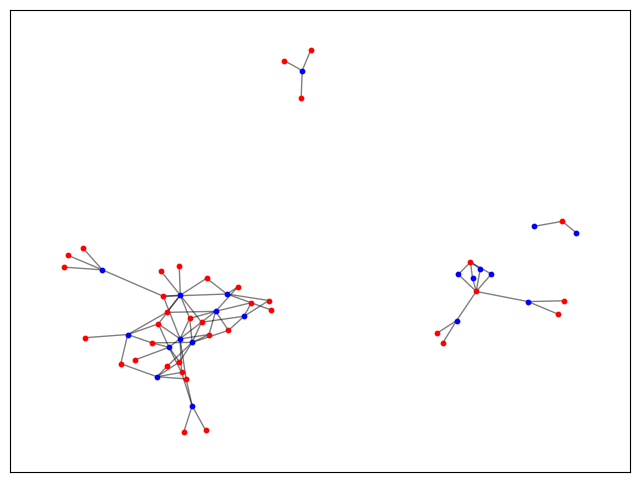

In [ ]:
# Homogeneous graph - G
G = nx.Graph()

# Add nodes for reviewers and products
G.add_nodes_from(reviewerID, bipartite=0)
G.add_nodes_from(products, bipartite=1)

# Add edges betwen reviewers and products
for edge in B.edges():
  G.add_edge(edge[0], edge[1])

# Create sets of reviewers and products
reviewers = []
products = []
for node, bip in G.nodes(data=True):
  if bip['bipartite'] == 0:
    reviewers.append(node)
  else:
    products.append(node)

# Plotting 
pos = nx.spring_layout(G) # spring layout

plt.figure(figsize=(8,6))
nx.draw_networkx_nodes(G, pos, nodelist=reviewers, node_size=10, node_color='blue') # reviewers are blue
nx.draw_networkx_nodes(G, pos, nodelist=products, node_size=10, node_color='red') # products are red
nx.draw_networkx_edges(G, pos, alpha=0.5)
plt.show()

# II. Larger Dataset (Musical_Instruments)

## a. Read the Larger Data

In [ ]:
# Read Data
data = []
with gzip.open('/content/Musical_Instruments_5.json.gz') as f:
    for l in f:
        data.append(json.loads(l.strip()))

print('The number of reviews: ', len(data))
reviews = pd.DataFrame.from_dict(data)
reviews = reviews[['reviewerID', 'asin', 'overall']]
reviews.head()

The number of reviews:  231392


,reviewerID,asin,overall
0,A3FO5AKVTFRCRJ,0739079891,5.0
1,A3UCGC1DHFMBCE,0739079891,5.0
2,A2S9SLRYLPGYZB,0739079891,5.0
3,A15RTJWPG8OKOE,0739079891,4.0
4,A12ET1WO3OAVU7,0739079891,1.0


In [ ]:
# Bipartite Graph - B
B = nx.Graph()

reviewerID = reviews['reviewerID'].unique()
products = reviews['asin'].unique()

B.add_nodes_from(reviewerID, bipartite=0)
B.add_nodes_from(products, bipartite=1)

edges, weighted_edges = add_bipartite_edges(reviews, B, 0, 1, 2)

print('Total number of nodes: ', B.number_of_nodes())
print('Total number of edges: ', B.number_of_edges())

Total number of nodes:  38150
Total number of edges:  219156


In [ ]:
# Homogeneous graph - G
G = nx.Graph()

G.add_nodes_from(reviewerID, bipartite=0)
G.add_nodes_from(products, bipartite=1)

for edge in B.edges():
  G.add_edge(edge[0], edge[1])

# Create lists to store reviewers and products
reviewers = []
products = []
for node, bip in G.nodes(data=True):
  if bip['bipartite'] == 0:
    reviewers.append(node)
  else:
    products.append(node)

print('Number of reviewers: ', len(reviewers))
print('Number of products: ', len(products))

Number of reviewers:  27530
Number of products:  10620


## b. Define the GCN Model

In [ ]:
# Autoencoder
class Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels) # first convolution
        self.conv2 = GCNConv(hidden_channels, out_channels) # second convolution layer

    # Encoder: learns the representation through the first layer
    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)

    # Decoder: aggregates the embeddings
    def decode(self, z, edge_label_index):
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(
            dim=-1
        )

    def decode_all(self, z):
        prob_adj = z @ z.t() # create a probability matrix
        return (prob_adj > 0).nonzero(as_tuple=False).t() # finds the indices of non-zero elements

## c. Training Loop

In [ ]:
def train_link_predictor(model, train_data, val_data, optimizer, criterion, n_epochs=100):
    train_losses = []
    val_aucs = []
    
    # loop through the number of required epochs
    for epoch in range(1, n_epochs + 1):
        optimizer.zero_grad()
        z = model.encode(train_data.x, train_data.edge_index)

        # sampling training negatives for every training epoch
        neg_edge_index = negative_sampling(
            edge_index=train_data.edge_index, num_nodes=train_data.num_nodes,
            num_neg_samples=train_data.edge_label_index.size(1), method='sparse')

        edge_label_index = torch.cat(
            [train_data.edge_label_index, neg_edge_index],
            dim=-1,
        )
        edge_label = torch.cat([
            train_data.edge_label,
            train_data.edge_label.new_zeros(neg_edge_index.size(1))
        ], dim=0)

        out = model.decode(z, edge_label_index).view(-1)
        loss = criterion(out, edge_label)
        loss.backward()
        optimizer.step()

        val_auc = eval_link_predictor(model, val_data)

        train_losses.append(loss.item())
        val_aucs.append(val_auc)

        if epoch % 10 == 0:
            print(f"Epoch: {epoch:03d}, Train Loss: {loss:.3f}, Val AUC: {val_auc:.3f}")
  
    return model, train_losses, val_aucs


@torch.no_grad()
def eval_link_predictor(model, data):
    """
    Compute AUC (Area Under the Curve): 
      a single scalar that measures how well a model performs
      ranges from 0 to 1 (0 the worst /1 the best)
    1. AUC = 0.5: random guessing
    2. AUC > 0.5: the model performs better than random guessing
    3. AUC > 0.7: the model can well predicts the true performance

    """

    model.eval()
    z = model.encode(data.x, data.edge_index)
    out = model.decode(z, data.edge_label_index).view(-1).sigmoid()

    return roc_auc_score(data.edge_label.cpu().numpy(), out.cpu().numpy())

## d. Feature Extraction

In [ ]:
# Compute the average ratings on reviewers and products
rev_ratings = reviews.groupby('reviewerID')['overall'].mean()
prod_ratings = reviews.groupby('asin')['overall'].mean()

# convert it to data framea
rev_ratings = pd.DataFrame(rev_ratings)
prod_ratings = pd.DataFrame(prod_ratings)

print('Average ratings of reviewers: ', list(rev_ratings['overall']))
print('Average ratings of products: ', list(prod_ratings['overall']))
print('Length of reviewer ratings: ', len(list(rev_ratings['overall'])))
print('Length of product ratings: ', len(list(prod_ratings['overall'])))

Average ratings of reviewers:  [3.6, 4.8, 4.4, 5.0, 4.4, 3.7142857142857144, 4.333333333333333, 4.4, 4.285714285714286, 4.131578947368421, 4.5, 3.5, 4.0, 4.666666666666667, 4.666666666666667, 3.4, 4.7, 4.777777777777778, 5.0, 5.0, 4.4, 4.6, 4.142857142857143, 4.142857142857143, 3.375, 4.833333333333333, 4.444444444444445, 4.714285714285714, 5.0, 4.4, 4.857142857142857, 5.0, 4.6, 5.0, 4.8, 5.0, 2.6, 4.0, 3.3333333333333335, 4.8, 4.2, 4.8, 4.769230769230769, 4.444444444444445, 4.8, 4.2, 3.6666666666666665, 3.4, 4.777777777777778, 5.0, 4.285714285714286, 4.6, 5.0, 4.4, 5.0, 3.6875, 3.8, 4.4, 3.6666666666666665, 4.7, 4.833333333333333, 3.5, 4.4, 5.0, 5.0, 4.166666666666667, 4.073170731707317, 5.0, 3.7142857142857144, 4.0, 4.555555555555555, 5.0, 4.4, 4.285714285714286, 5.0, 4.833333333333333, 3.888888888888889, 4.5, 3.5, 4.166666666666667, 3.6666666666666665, 4.0, 4.142857142857143, 4.2, 5.0, 4.166666666666667, 4.8, 4.2727272727272725, 4.6, 5.0, 4.857142857142857, 4.222222222222222, 5.0, 4

In [ ]:
# Unique reviewers and products
reviewers = reviews['reviewerID'].unique()
products = reviews['asin'].unique()

# Create a dictionary: mapping the reviewers first, and then products
reviewer_to_index = {reviewer: i for i, reviewer in enumerate(reviewers)}
product_to_index = {product: i + len(reviewers) for i, product in enumerate(products)}

# Create an empty feature matrix with the appropriate size
num_reviewers = len(reviewers)
num_products = len(products)
num_features = 1
feature = torch.zeros(num_reviewers + num_products, num_features)

# Set the feature values for reviewers
for reviewer, rating in zip(reviewers, rev_ratings['overall']):
    reviewer_index = reviewer_to_index[reviewer]
    feature[reviewer_index, 0] = rating

# Set the feature values for products
for product, rating in zip(products, prod_ratings['overall']):
    product_index = product_to_index[product]
    feature[product_index, 0] = rating

feature = feature.float()

# Print the size of the feature matrix
print(feature.size())

np_feature = feature.numpy()
feature_list = []
for ft in range(len(np_feature)):
  feature_list.append(np_feature[ft][0])

print('Length of feature list: ', len(feature_list))

torch.Size([38150, 1])
Length of feature list:  38150


## e. New Homogeneous Graph

In [ ]:
# New Homogeneous Graph - G_new
G_new = nx.Graph()

G_new.add_nodes_from(reviewers, bipartite=0)
G_new.add_nodes_from(products, bipartite=1)

for edge in B.edges():
  G_new.add_edge(edge[0], edge[1])

# Add features (the average ratings) into nodes
rating_dict = dict(zip(G_new.nodes(),feature_list))
nx.set_node_attributes(G_new, rating_dict, name="rating")

print(rating_dict)

{'A3FO5AKVTFRCRJ': 3.6, 'A3UCGC1DHFMBCE': 4.8, 'A2S9SLRYLPGYZB': 4.4, 'A15RTJWPG8OKOE': 5.0, 'A12ET1WO3OAVU7': 4.4, 'A2WXECU99NYBAZ': 3.7142856, 'A262B8XPOW9XAR': 4.3333335, 'A2MPUHYCHTNFAV': 4.4, 'A38EESXGXN9YLB': 4.285714, 'ABLTNLVKCVQMK': 4.131579, 'A1H4I7VO8YVMEI': 4.5, 'A1NZF2Y9MQD5QA': 3.5, 'A24K057TXUJASY': 4.0, 'A1XN2ORFU4W0SY': 4.6666665, 'A277ZN2W6AIR4L': 4.6666665, 'A1J6YHDF0BX9MU': 3.4, 'AKBCG98VTCOCQ': 4.7, 'A2THM1GQ56G1G9': 4.7777777, 'A13EZZ0NKHYNUD': 5.0, 'A99K7S15XOQ45': 5.0, 'A13NZBZQ7ZZG5O': 4.4, 'A3RI2C0RY4DHK': 4.6, 'AH0XON4XDOF2C': 4.142857, 'A224LOZUTJTM3O': 4.142857, 'A28FADP9FITQVK': 3.375, 'A7SV98BQ4X543': 4.8333335, 'AOCBJFQ7UPEOJ': 4.4444447, 'AVY28JSKAJXSY': 4.714286, 'A2TXRC7ZTIAASG': 5.0, 'A2W58NITMCTCP': 4.4, 'A1IU7S4HCK1XK0': 4.857143, 'A3DGJMO6VPG6FJ': 5.0, 'A2SCX4SDWW1WN6': 4.6, 'ABK5DXK7BZ8JJ': 5.0, 'A37M5LMB7BDGQJ': 4.8, 'ACOAXGKSE4LXN': 5.0, 'A19KOCD0UWK736': 2.6, 'AV9E7SJWU0PQ9': 4.0, 'A3CEV9KBYLPK2L': 3.3333333, 'A2ZPY4IM17L09F': 4.8, 'AUKVM8TXMB

## f. Split the Data into Training, Testing, and Validation Randomly

In [ ]:
# Convert the NetworkX graph 'G' to a PyTorch Geometric Data object
data = from_networkx(G)

split = T.RandomLinkSplit(
    num_val=0.1, #validation set 10%
    num_test=0.1, #test set 10%
    is_undirected=True,
    add_negative_train_samples=False,
    neg_sampling_ratio=1.0,
)

train_data, val_data, test_data = split(data)

# assign the features
train_data.x = feature
test_data.x = feature
val_data.x = feature

In [ ]:
print(G.number_of_edges())
print('train data:', train_data)
print('test data:', test_data)
print('val data:', val_data)

219156
train data: Data(edge_index=[2, 372568], bipartite=[38150], num_nodes=38150, edge_label=[186284], edge_label_index=[2, 186284], x=[38150, 1])
test data: Data(edge_index=[2, 394482], bipartite=[38150], num_nodes=38150, edge_label=[43830], edge_label_index=[2, 43830], x=[38150, 1])
val data: Data(edge_index=[2, 372568], bipartite=[38150], num_nodes=38150, edge_label=[21914], edge_label_index=[2, 21914], x=[38150, 1])


## g. Results

Epoch: 010, Train Loss: 0.738, Val AUC: 0.761
Epoch: 020, Train Loss: 0.655, Val AUC: 0.749
Epoch: 030, Train Loss: 0.648, Val AUC: 0.760
Epoch: 040, Train Loss: 0.638, Val AUC: 0.788
Epoch: 050, Train Loss: 0.630, Val AUC: 0.802
Epoch: 060, Train Loss: 0.624, Val AUC: 0.809
Epoch: 070, Train Loss: 0.619, Val AUC: 0.812
Epoch: 080, Train Loss: 0.615, Val AUC: 0.814
Epoch: 090, Train Loss: 0.613, Val AUC: 0.813
Epoch: 100, Train Loss: 0.610, Val AUC: 0.810
Test AUC: 0.808


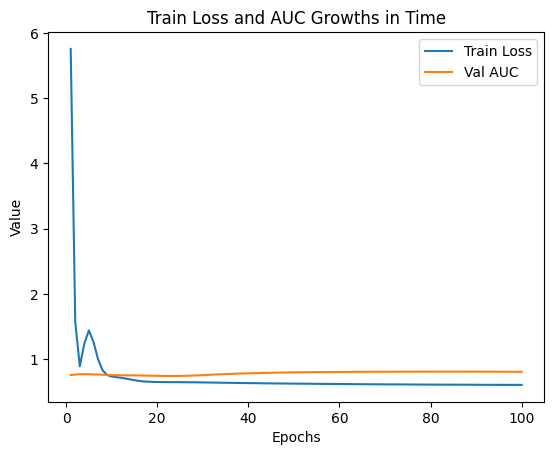

In [ ]:
in_channels = 1
hidden_channels = 128  
out_channels = 64 

#create the model object
model = Net(in_channels, hidden_channels, out_channels)

# Define the optimizer
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.01)

# Define the criterion
criterion = torch.nn.BCEWithLogitsLoss()

# Train the link predictor
model, train_losses, val_aucs  = train_link_predictor(model, train_data, val_data, optimizer, criterion)

# Evaluate the model on the test data
test_auc = eval_link_predictor(model, test_data)
print(f"Test AUC: {test_auc:.3f}")


# Visualize the learning progress
epochs = range(1, len(train_losses) + 1)

plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_aucs, label='Val AUC')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Train Loss and AUC Growths in Time')
plt.legend()
plt.show()

# LIGHTGCN MODEL

In [ ]:
data = []
with gzip.open('/content/Musical_Instruments_5.json.gz') as f:
    for l in f:
        data.append(json.loads(l.strip()))

df = pd.DataFrame(data)
df.head()

,overall,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,vote,style,image
0,5.0,True,"10 30, 2016",A3FO5AKVTFRCRJ,0739079891,francisco,It's good for beginners,Five Stars,1477785600,NaN,NaN,NaN
1,5.0,True,"06 30, 2016",A3UCGC1DHFMBCE,0739079891,Eb Jack Murray,I recommend this starter Ukulele kit. I has e...,Five Stars,1467244800,NaN,NaN,NaN
2,5.0,True,"05 9, 2016",A2S9SLRYLPGYZB,0739079891,Clara LaMarr,G'daughter received this for Christmas present...,Learning new songs to play regularly,1462752000,NaN,NaN,NaN
3,4.0,True,"04 10, 2016",A15RTJWPG8OKOE,0739079891,Eagle80,"According to my order history, I bought this t...",A bargain-bin good-enough ukulele that's held ...,1460246400,NaN,NaN,NaN
4,1.0,True,"02 6, 2016",A12ET1WO3OAVU7,0739079891,Amazon Customer,Please pay attention better than I did to the ...,Poor Quality product.,1454716800,NaN,NaN,NaN


In [ ]:
reviews_df = df[['reviewerID', 'asin', 'overall']]
reviews_df.head()

,reviewerID,asin,overall
0,A3FO5AKVTFRCRJ,0739079891,5.0
1,A3UCGC1DHFMBCE,0739079891,5.0
2,A2S9SLRYLPGYZB,0739079891,5.0
3,A15RTJWPG8OKOE,0739079891,4.0
4,A12ET1WO3OAVU7,0739079891,1.0


In [ ]:
# Get all distinct reviewers and songs in the dataset
reviewers_map = {}
products_map = {}
for i, r in enumerate(reviews_df['reviewerID'].unique()):
  reviewers_map[r] = i
for i, p in enumerate(reviews_df['asin'].unique()):
  products_map[p] = i
  
print(reviewers_map) # {rev : id}
print(products_map) # {prod : id}

{'A3FO5AKVTFRCRJ': 0, 'A3UCGC1DHFMBCE': 1, 'A2S9SLRYLPGYZB': 2, 'A15RTJWPG8OKOE': 3, 'A12ET1WO3OAVU7': 4, 'A2WXECU99NYBAZ': 5, 'A262B8XPOW9XAR': 6, 'A2MPUHYCHTNFAV': 7, 'A38EESXGXN9YLB': 8, 'ABLTNLVKCVQMK': 9, 'A1H4I7VO8YVMEI': 10, 'A1NZF2Y9MQD5QA': 11, 'A24K057TXUJASY': 12, 'A1XN2ORFU4W0SY': 13, 'A277ZN2W6AIR4L': 14, 'A1J6YHDF0BX9MU': 15, 'AKBCG98VTCOCQ': 16, 'A2THM1GQ56G1G9': 17, 'A13EZZ0NKHYNUD': 18, 'A99K7S15XOQ45': 19, 'A13NZBZQ7ZZG5O': 20, 'A3RI2C0RY4DHK': 21, 'AH0XON4XDOF2C': 22, 'A224LOZUTJTM3O': 23, 'A28FADP9FITQVK': 24, 'A7SV98BQ4X543': 25, 'AOCBJFQ7UPEOJ': 26, 'AVY28JSKAJXSY': 27, 'A2TXRC7ZTIAASG': 28, 'A2W58NITMCTCP': 29, 'A1IU7S4HCK1XK0': 30, 'A3DGJMO6VPG6FJ': 31, 'A2SCX4SDWW1WN6': 32, 'ABK5DXK7BZ8JJ': 33, 'A37M5LMB7BDGQJ': 34, 'ACOAXGKSE4LXN': 35, 'A19KOCD0UWK736': 36, 'AV9E7SJWU0PQ9': 37, 'A3CEV9KBYLPK2L': 38, 'A2ZPY4IM17L09F': 39, 'AUKVM8TXMBUR5': 40, 'A1M5X1ILU4ZOWT': 41, 'A3OULY1DYPR5R8': 42, 'A2T2PJ8BWUO7D': 43, 'A1IVXL7131OOIW': 44, 'A3DMRLRVT0KRTE': 45, 'A2053ZJUGC

In [ ]:
# Create Edge Index
edge_index = [[], []]
for i, row in reviews_df.iterrows():
  edge_index[0].append(reviewers_map[row['reviewerID']])
  edge_index[1].append(products_map[row['asin']])
edge_index = torch.tensor(edge_index) 

print(edge_index) # [[rev1_id, rev2_id, ...], [prod1_id, prod2_id, ...]]

tensor([[    0,     1,     2,  ..., 17968,  3949, 27317],
        [    0,     0,     0,  ..., 10619, 10619, 10619]])


In [ ]:
# Get total number of reviewers, songs, and ratings
reviewers_count = len(reviewers_map)
products_count = len(products_map)
ratings_count = len(reviews_df)
ratings_index = np.arange(ratings_count)
print(reviewers_count, ' ', products_count, ' ', ratings_count, ' ', ratings_index)

27530   10620   231392   [     0      1      2 ... 231389 231390 231391]


In [ ]:
# split dataset into train, validation, test subsets
train_index, val_test_index = train_test_split(ratings_index, test_size = 0.2, random_state = 168)
val_index, test_index = train_test_split(val_test_index, test_size=0.5, random_state=168)

# get edge_index of the respective subsets
train_edge_index = edge_index[:, train_index]
val_edge_index = edge_index[:, val_index]
test_edge_index = edge_index[:, test_index]

In [ ]:
# Convert edge_index of each subset to SparseTensor for training
nodes_count = reviewers_count + products_count
train_sparse = SparseTensor(row=train_edge_index[0], col=train_edge_index[1], sparse_sizes=(nodes_count, nodes_count))
val_sparse = SparseTensor(row=val_edge_index[0], col=val_edge_index[1], sparse_sizes=(nodes_count, nodes_count))
test_sparse = SparseTensor(row=test_edge_index[0], col=test_edge_index[1], sparse_sizes=(nodes_count, nodes_count))

LightGCN MODEL

In [ ]:
class LightGCN(MessagePassing):
  '''
  LightGCN Model
  '''
  def __init__(self, reviewers_count, products_count, hidden_ch, layers_count):
    super().__init__()

    self.reviewers_count = reviewers_count
    self.products_count = products_count
    self.hidden_ch = hidden_ch
    self.layers_count = layers_count

    # a simple lookup table that stores embeddings of a fixed dictionary and size.
    self.r_emb = nn.Embedding(self.reviewers_count, self.hidden_ch) 
    self.p_emb = nn.Embedding(self.products_count, self.hidden_ch)

    # initialise weights with a normal distribution
    nn.init.normal_(self.r_emb.weight, std=0.1)
    nn.init.normal_(self.p_emb.weight, std=0.1)

  '''
  Forward Passing, returns initial and final embeddings of reviewers and products
  '''
  def forward(self, edge_index):
    # Applies the GCN normalization from the "Semi-supervised Classificationwith Graph Convolutional Networks"
    edge_index_norm = gcn_norm(edge_index, False) 

    # First layer, concat embeddings
    emb_0 = torch.cat([self.r_emb.weight, self.p_emb.weight])
    emb_s = [emb_0]
    emb_i = emb_0

    # pass embedding to the next layer
    for i in range(self.layers_count):
      emb_i = self.propagate(edge_index_norm, x=emb_i)
      emb_s.append(emb_i)
    
    emb_s = torch.stack(emb_s, dim=1)
    emb_final = torch.mean(emb_s, dim=1)

    r_emb, p_emb = torch.split(emb_final, [self.reviewers_count, self.products_count])

    return r_emb, self.r_emb.weight, p_emb, self.p_emb.weight

  def propagate(self, edge_index, x):
    x = self.message_and_aggregate(edge_index, x)
    return x

  def message(self, x):
    return x
  
  def message_and_aggregate(self, edge_index, x):
    return matmul(edge_index, x)

HELPER FUNCTIONS

Mini-batch Sampling

In [ ]:
# Minibatch Sampling
'''
The following function randomly samples the index of a mini-batch by an adjacency matrix.
PARAM:
  batch_size (int): desired batch size (e.g. 256)
  edge_index (torch.Tensor): 2xN tensor of the edges
OUTPUT:
  reviewers_index (torch.Tensor): index of the users in the sampled edge
  pos_products_index (torch.Tensor): index of the positive products in the sampled edge
  neg_products_index (torch.Tensor): index of the negative products in the sampled edge
'''
def mini_batch(edge_index, batch_size):
  edges = structured_negative_sampling(edge_index, num_nodes=len(torch.unique(edge_index[1])))
  edges = torch.stack(edges, dim=0) # Concatenates a sequence of tensors along a new dimension
  index = torch.randperm(edges.shape[1])[:batch_size] # random permutation of integers from 0 to n - 1
  batch = edges[:, index]
  reviewers_index, pos_product_index, neg_product_index = batch[0], batch[1], batch[2]

  return reviewers_index, pos_product_index, neg_product_index

In [ ]:
# Bayesian Personalized Ranking Loss.
'''
The following function calculates the BPR loss
PARAM:
  r_emb_0 (torch.Tensor): initial user embedding
  r_emb (torch.Tensor): final user embedding
  pos_emb_0 (torch.Tensor): initial positive product embedding
  pos_emb (torch.Tensor): final positive product embedding
  neg_emb_0 (torch.Tensor): initial negative product embedding
  neg_emb (torch.Tensor): final negative product embedding
  lambda_val (float): L2 regulatization strength
OUTPUT:
  loss (float): BPR Loss
'''
def bpr_loss(r_emb_0, r_emb, pos_emb_0, pos_emb, neg_emb_0, neg_emb, lambda_val):
  pos_scores = torch.sum(r_emb * pos_emb, dim=1)
  neg_scores = torch.sum(r_emb * neg_emb, dim=1)
  losses = -torch.log(torch.sigmoid(pos_scores - neg_scores))
  loss = torch.mean(losses) + lambda_val * (torch.norm(r_emb_0) + torch.norm(pos_emb_0) + torch.norm(neg_emb_0))

  return loss

Positive Products

In [ ]:
# get positive products for train/test data subsets
'''
Return positive products for all users in a list
PARAM:
  edge_index (torch.Tensor): Edge Index of reviewer-product connections
OUTPUT:
  pos_products (torch.Tensor): a list of positive products for all users
'''
def positive_products(edge_index):
  pos_products = {}
  for i in range(edge_index.shape[1]):
    reviewer = edge_index[0][i].item()
    product = edge_index[1][i].item()
    if reviewer not in pos_products:
        pos_products[reviewer] = []
    pos_products[reviewer].append(product)

  return pos_products

Recall and Precision at K

In [ ]:
# Return the recall and precision metrics at k
'''
Calculates recall and precision at k
PARAM:
  actual_r:
  pred_r:
  k:
OUTPUT:
  recall.item():
  precision.item():
'''
def recall_precision_k(actual_r, pred_r, k):
  correct_count = torch.sum(pred_r, dim=-1)
  
  # number of products liked by each user in the test data subset
  liked_count = []
  for i in range(len(actual_r)):
    liked_count.append(len(actual_r[i]))
  liked_count = torch.Tensor(liked_count)

  recall = torch.mean(correct_count/liked_count)
  precision = torch.mean(correct_count)/k

  return recall.item(), precision.item()

EVALUATION

In [ ]:
'''
Evaluates the model's BPR loss and Recall & Precision metrics
PARAM:
  model: LightGCN Model
  edge_index (torch.Tensor): Edges for the split
  sparse_edge_index (SparseTensor): Sparse Adj Matrix
  mask_index (torch.Tensor): A list of edges to be removed from the evaluation
  k (int): Top K items to consider
OUTPUT: 
  loss: loss value of the model on the given split
  recall: recall value of the model on the given split
  precision: precision value of the model on the given split
'''

def evaluation(model, edge_index, sparse_edge_index, mask_index, k, lambda_val):
  # get embeddings and calculate loss
  r_emb, r_emb_0, p_emb, p_emb_0 = model.forward(sparse_edge_index)
  edges = structured_negative_sampling(edge_index, num_nodes=len(torch.unique(edge_index[1])), contains_neg_self_loops=False)

  r_index, pos_index, neg_index = edges

  r_emb, r_emb_0 = r_emb[r_index], r_emb_0[r_index]
  pos_emb, pos_emb_0 = p_emb[pos_index], p_emb_0[pos_index]
  neg_emb, neg_emb_0 = p_emb[neg_index], p_emb_0[neg_index]

  loss = bpr_loss(r_emb_0, r_emb, pos_emb_0, pos_emb, neg_emb_0, neg_emb, lambda_val).item()
  
  r_emb_w = model.r_emb.weight
  p_emb_w = model.p_emb.weight

  # Create rating matrix for reviewer and product, mask out existing ratings
  rating = torch.matmul(r_emb_w, p_emb_w.T)

  for i in mask_index:
    reviewer_pos_products = positive_products(i)
    masked_r = []
    masked_p = []
    for r, p in reviewer_pos_products.items():
      masked_r.extend([r] * len(p))
      masked_p.extend(p)
    
    rating[masked_r, masked_p] = float("-inf") # ratings masked out

  _, top_K_products = torch.topk(rating, k=k)
  
  # Get all distinct users and actual ratings for evaluation
  reviewers = edge_index[0].unique()
  test_reviewer_pos_products = positive_products(edge_index)
 
  actual_ratings = []
  predict_ratings = []
  for r in reviewers:
    actual_ratings.append(test_reviewer_pos_products[r.item()])
  for r in reviewers:
    products = test_reviewer_pos_products[r.item()]
    label = list(map(lambda x: x in products, top_K_products[r]))
    predict_ratings.append(label)
  predict_ratings = torch.Tensor(np.array(predict_ratings).astype('float'))
 
  # get recall and precision metrics
  recall, precision = recall_precision_k(actual_ratings, predict_ratings, k)

  return loss, recall, precision

LightGCN MODEL TRAINING

In [ ]:
# Model Configuration
batch_size = 256
num_epoch = 50
epoch_size = 200
lr = 1e-3
lr_decay = 0.9
topK = 20
lambda_val = 1e-6
hidden_ch = 32
layer_count = 3

model = LightGCN(reviewers_count, products_count, hidden_ch, layer_count)

In [ ]:
# Setup
device = torch.device('cpu') # 'cuda' if available

model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
edge_index = edge_index.to(device)
train_edge_index = train_edge_index.to(device)
train_sparse = train_sparse.to(device)
val_edge_index = val_edge_index.to(device)
val_sparse = val_sparse.to(device)

In [ ]:
# Training

train_losses = []
val_losses = []
recalls = []
precisions = []

for epoch in range(num_epoch):
  for i in range(epoch_size):
    # forward propagation
    r_emb, r_emb_0, p_emb, p_emb_0 = model.forward(train_sparse)

    # minibatch sampling
    r_index, pos_index, neg_index = mini_batch(train_edge_index, batch_size)

    r_index = r_index.to(device)
    pos_index = pos_index.to(device)
    neg_index = neg_index.to(device)

    r_emb, r_emb_0 = r_emb[r_index], r_emb_0[r_index]
    pos_emb, pos_emb_0 = p_emb[pos_index], p_emb_0[pos_index]
    neg_emb, neg_emb_0 = p_emb[neg_index], p_emb_0[neg_index]

    # bpr loss
    loss = bpr_loss(r_emb_0, r_emb, pos_emb_0, pos_emb, neg_emb_0, neg_emb, lambda_val)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  
  model.eval()
  val_loss, recall, precision = evaluation(model, val_edge_index, val_sparse, [train_edge_index], topK, lambda_val)

  print(f'EPOCH: {epoch}',f'train_loss: {loss:.3f}',f'val_loss: {val_loss:.3f}',f'recall: {recall:.3f}',f'precision: {precision:.3f}')

  train_losses.append(loss.item())
  val_losses.append(val_loss)
  recalls.append(recall)
  precisions.append(precision)
  scheduler.step()

EPOCH: 0 train_loss: 0.619 val_loss: 0.603 recall: 0.031 precision: 0.002
EPOCH: 1 train_loss: 0.527 val_loss: 0.527 recall: 0.051 precision: 0.004
EPOCH: 2 train_loss: 0.494 val_loss: 0.487 recall: 0.058 precision: 0.004
EPOCH: 3 train_loss: 0.458 val_loss: 0.468 recall: 0.063 precision: 0.005
EPOCH: 4 train_loss: 0.451 val_loss: 0.458 recall: 0.064 precision: 0.005
EPOCH: 5 train_loss: 0.449 val_loss: 0.452 recall: 0.066 precision: 0.005
EPOCH: 6 train_loss: 0.423 val_loss: 0.449 recall: 0.066 precision: 0.005
EPOCH: 7 train_loss: 0.454 val_loss: 0.448 recall: 0.067 precision: 0.005
EPOCH: 8 train_loss: 0.425 val_loss: 0.445 recall: 0.066 precision: 0.005
EPOCH: 9 train_loss: 0.433 val_loss: 0.442 recall: 0.067 precision: 0.005
EPOCH: 10 train_loss: 0.407 val_loss: 0.443 recall: 0.067 precision: 0.005
EPOCH: 11 train_loss: 0.485 val_loss: 0.438 recall: 0.067 precision: 0.005
EPOCH: 12 train_loss: 0.396 val_loss: 0.439 recall: 0.068 precision: 0.005
EPOCH: 13 train_loss: 0.404 val_los

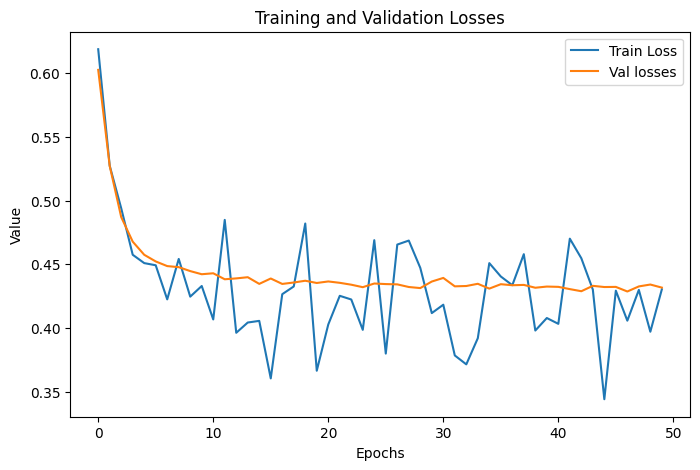

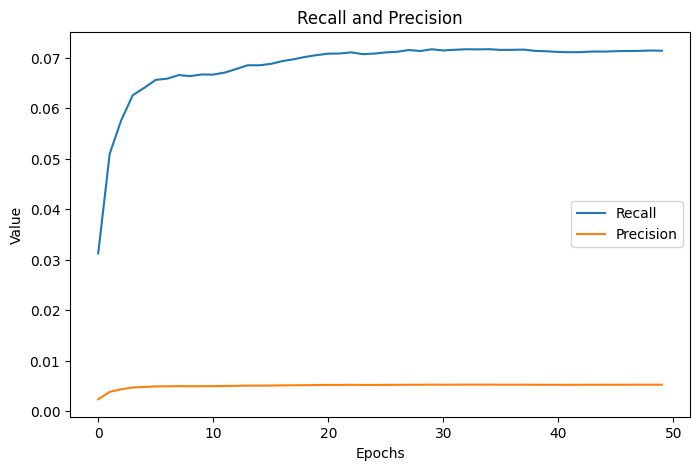

In [ ]:
from logging import logProcesses
logProcesses# Train_loss and Val_loss Graph
epochs = range(len(train_losses))

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val losses')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs, recalls, label='Recall')
plt.plot(epochs, precisions, label='Precision')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Recall and Precision')
plt.legend()
plt.show()

In [ ]:
# Test set evaluation
model.eval()
test_sparse = test_sparse.to(device)
test_edge_index = test_edge_index.to(device)
test_loss, test_recall, test_precision = evaluation(model, test_edge_index, test_sparse, [train_edge_index, val_edge_index], topK, lambda_val) 

print(f'test_loss: {test_loss:.3f}',f'test_recall: {test_recall:.3f}',f'test_precision: {test_precision:.3f}')

test_loss: 0.442 test_recall: 0.068 test_precision: 0.005


In [ ]:
#Predict products that the reviewer is interested
def predict(reviewer_id, topK):
    '''
    Make top K recommendations
    '''
    # read info
    model.eval()
    pos_products = positive_products(edge_index)
    reviewer = reviewer_id
    reviewer_emb = model.r_emb.weight[reviewer]
    scores = model.p_emb.weight @ reviewer_emb

    values, indices = torch.topk(scores, k=len(pos_products[reviewer]) + topK)


    products = [index.cpu().item() for index in indices if index not in pos_products[reviewer]]
    topk_products = products[:topK]
    product_ids = [list(products_map.keys())[list(products_map.values()).index(product)] for product in products]
    
    print(f"suggested products for reviewer {reviewer_id}:")
    for i in range(topK):
      if i <= len(product_ids)-1:
        print(product_ids[i])
      else:
        break

predict(30, 10)
predict(20, 10)

suggested products for reviewer 30:
B000VJJQUU
B002UAF1PW
B0007Y09VO
B0002H0A3S
B0002E1G5C
B00063678K
B0002E1J3Q
B001PGXKC8
B0017H4EBG
B00IFOTSJW
suggested products for reviewer 20:
B0002E1NNC
B0002E1NWI
B004XNK7AI
B0002E1G5C
B00J4TBMVO
B0007Y09VO
B00IFOTSJW
B00646MZHK
B0002H0A3S
B005FKF1PY
